# E-Sports Player Performance & Tournament Analytics

EDA notebook performing the same core analysis pattern as the reference notebook, adapted to the provided E-Sports dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the provided CSV
df = pd.read_csv("esports_player_performance_tournament_analytics.csv")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (2800, 16)


,record_id,player_id,team_name,player_role,map_played,match_type,kills,assists,deaths,accuracy_percent,reaction_time_ms,fatigue_index,performance_score,win_probability,match_outcome,mvp_award
0,1,160,Titan Esports,Flex,Dust Arena,Playoff,18,6,7,40.43,192.28,0.52,50.02,0.83,Win,No
1,2,2,Titan Esports,Support,Neon City,Final,16,7,11,40.50,201.98,0.68,41.45,0.89,Win,No
2,3,468,Team Alpha,Support,Neon City,Semi-Final,14,7,15,36.93,172.50,0.27,35.77,0.81,Win,No
3,4,447,Team Nova,IGL,Desert Storm,Final,12,6,13,53.46,246.83,0.07,43.03,1.00,Win,No
4,5,196,Phantom Squad,Sniper,Skyline,Playoff,13,9,13,44.71,266.94,0.52,39.16,0.85,Win,No


In [3]:
# Data quality and structure checks
print("Missing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))


Missing values:


,missing_values
record_id,0
player_id,0
team_name,0
player_role,0
map_played,0
match_type,0
kills,0
assists,0
deaths,0
accuracy_percent,0



Duplicate rows: 0

Data types:


,dtype
record_id,int64
player_id,int64
team_name,str
player_role,str
map_played,str
match_type,str
kills,int64
assists,int64
deaths,int64
accuracy_percent,float64


## 1. Performance Distribution by Match Outcome

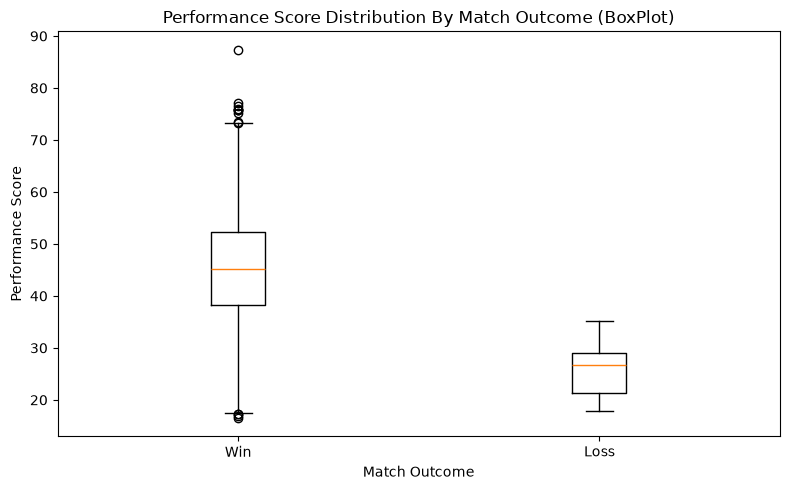

In [5]:
outcome_order = ["Win", "Loss"]
groups = [df.loc[df["match_outcome"] == outcome, "performance_score"] for outcome in outcome_order]

plt.figure(figsize=(8,5))
plt.boxplot(groups, tick_labels=outcome_order)
plt.title("Performance Score Distribution By Match Outcome (BoxPlot)")
plt.xlabel("Match Outcome")
plt.ylabel("Performance Score")
plt.tight_layout()
plt.show()


## 2. Performance Distribution by Match Outcome — Violin Plot

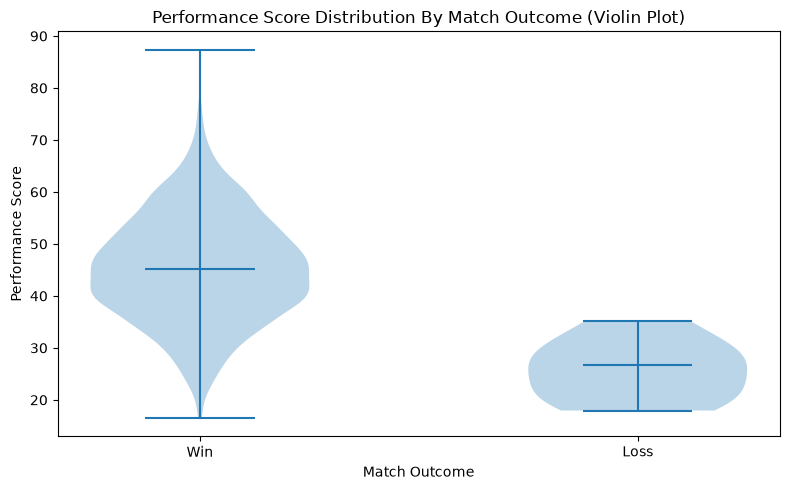

In [6]:
plt.figure(figsize=(8,5))
plt.violinplot(groups, showmeans=False, showmedians=True)
plt.xticks(range(1, len(outcome_order)+1), outcome_order)
plt.title("Performance Score Distribution By Match Outcome (Violin Plot)")
plt.xlabel("Match Outcome")
plt.ylabel("Performance Score")
plt.tight_layout()
plt.show()


## 3. Overall Performance Score Distribution

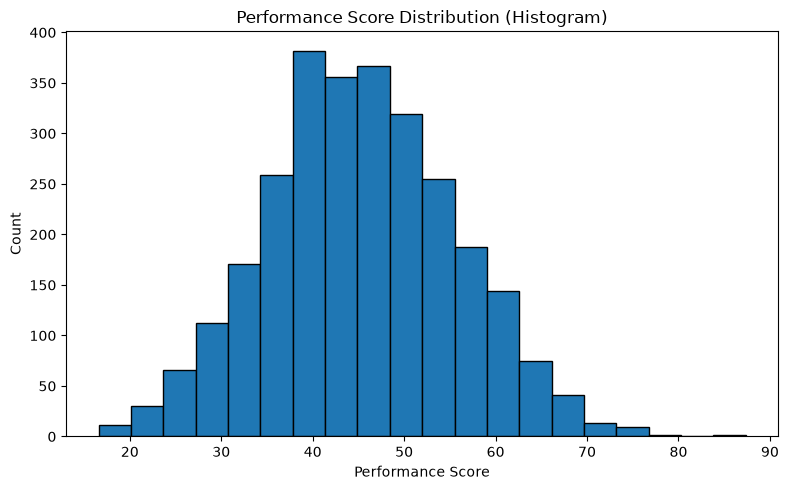

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df["performance_score"], bins=20, edgecolor="black")
plt.title("Performance Score Distribution (Histogram)")
plt.xlabel("Performance Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 4. Histogram Bin Experiments

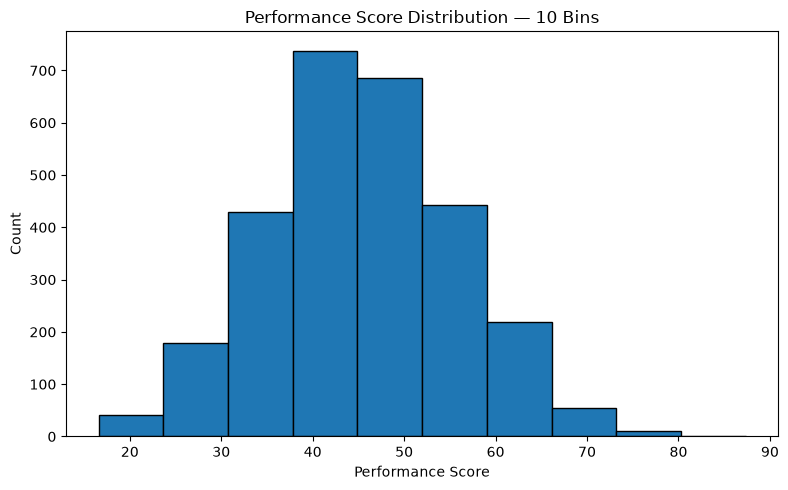

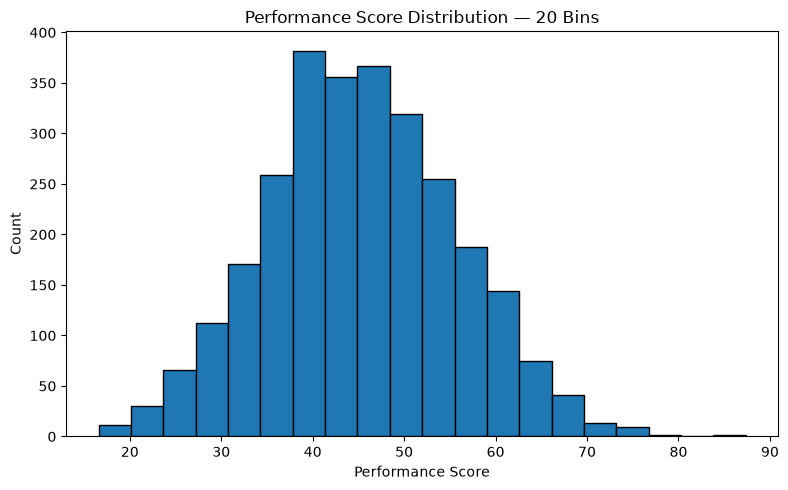

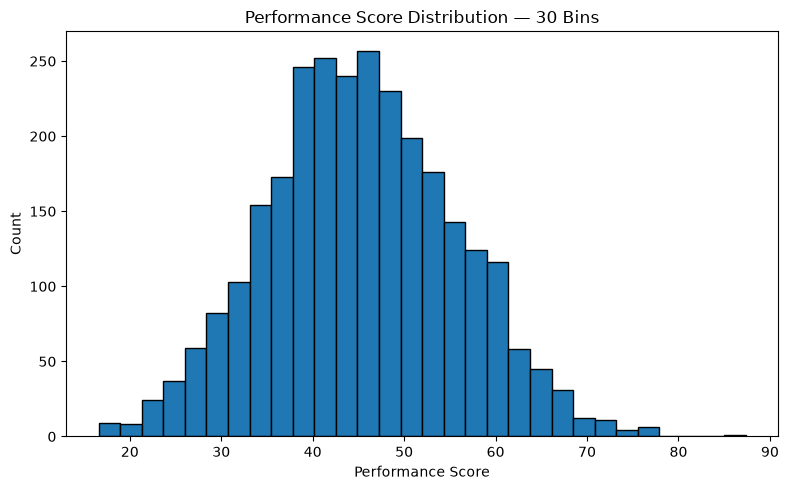

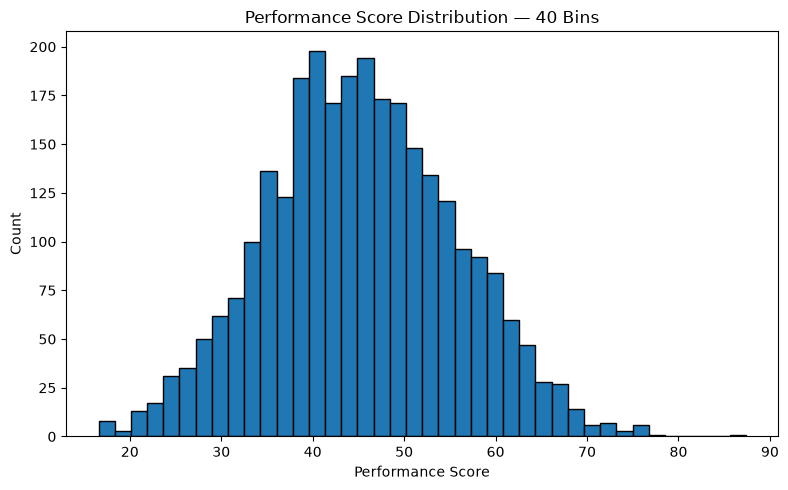

In [8]:
for bins in [10, 20, 30, 40]:
    plt.figure(figsize=(8,5))
    plt.hist(df["performance_score"], bins=bins, edgecolor="black")
    plt.title(f"Performance Score Distribution — {bins} Bins")
    plt.xlabel("Performance Score")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


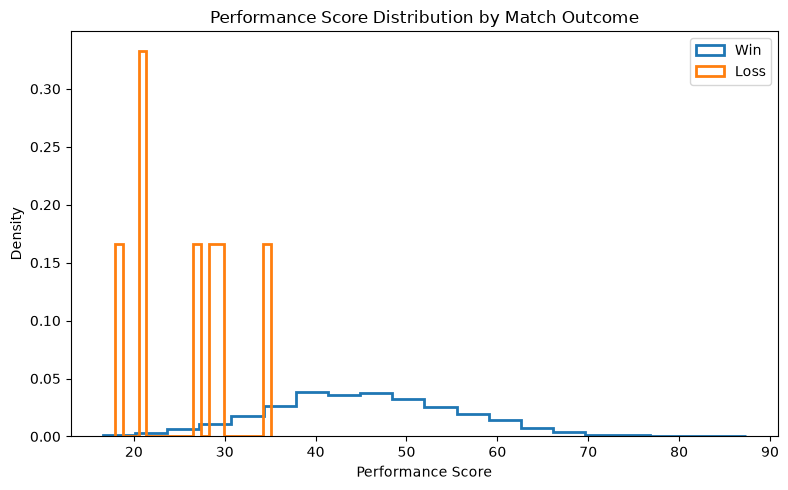

In [9]:
# Outcome-wise density-style distributions
plt.figure(figsize=(8,5))
for outcome in outcome_order:
    values = df.loc[df["match_outcome"] == outcome, "performance_score"]
    plt.hist(values, bins=20, density=True, histtype="step", linewidth=2, label=outcome)

plt.title("Performance Score Distribution by Match Outcome")
plt.xlabel("Performance Score")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Correlation Analysis

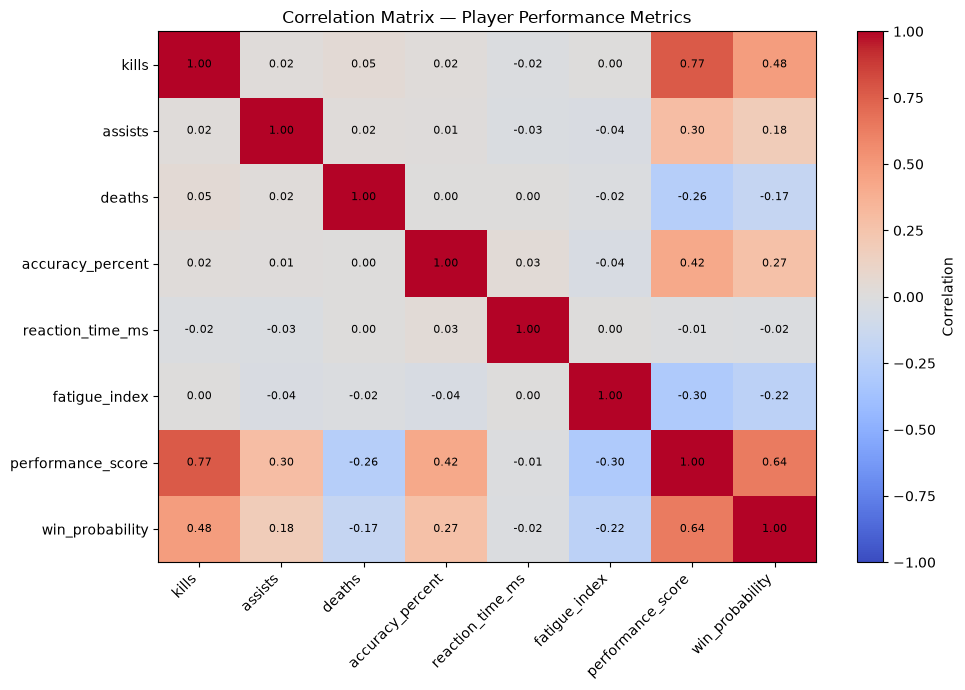

,kills,assists,deaths,accuracy_percent,reaction_time_ms,fatigue_index,performance_score,win_probability
kills,1.00,0.02,0.05,0.02,-0.02,0.00,0.77,0.48
assists,0.02,1.00,0.02,0.01,-0.03,-0.04,0.30,0.18
deaths,0.05,0.02,1.00,0.00,0.00,-0.02,-0.26,-0.17
accuracy_percent,0.02,0.01,0.00,1.00,0.03,-0.04,0.42,0.27
reaction_time_ms,-0.02,-0.03,0.00,0.03,1.00,0.00,-0.01,-0.02
fatigue_index,0.00,-0.04,-0.02,-0.04,0.00,1.00,-0.30,-0.22
performance_score,0.77,0.30,-0.26,0.42,-0.01,-0.30,1.00,0.64
win_probability,0.48,0.18,-0.17,0.27,-0.02,-0.22,0.64,1.00


In [10]:
numeric_cols = [
    "kills",
    "assists",
    "deaths",
    "accuracy_percent",
    "reaction_time_ms",
    "fatigue_index",
    "performance_score",
    "win_probability"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,7))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Correlation Matrix — Player Performance Metrics")
plt.tight_layout()
plt.show()

display(corr.round(2))


## 6. Additional EDA — Player Role

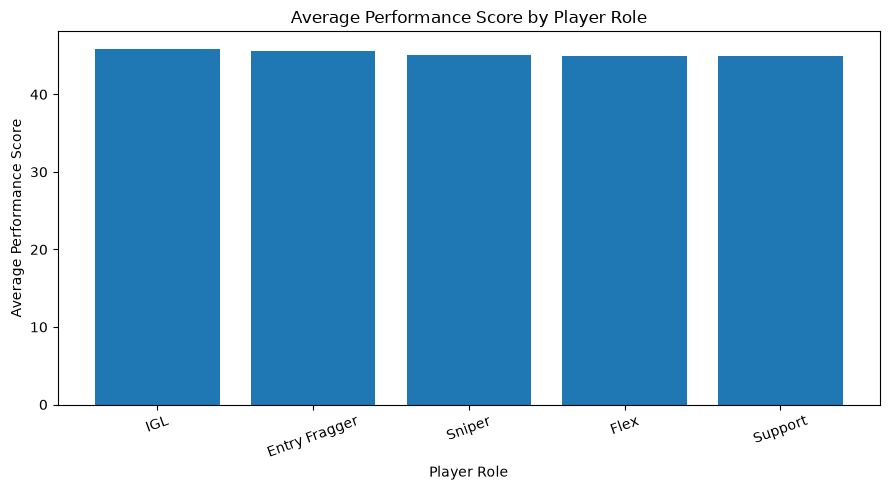

,average_performance_score
player_role,
IGL,45.83
Entry Fragger,45.57
Sniper,45.09
Flex,45.01
Support,44.99


In [11]:
role_perf = (
    df.groupby("player_role")["performance_score"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))
plt.bar(role_perf.index, role_perf.values)
plt.title("Average Performance Score by Player Role")
plt.xlabel("Player Role")
plt.ylabel("Average Performance Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(role_perf.to_frame("average_performance_score").round(2))


## 7. Additional EDA — Team

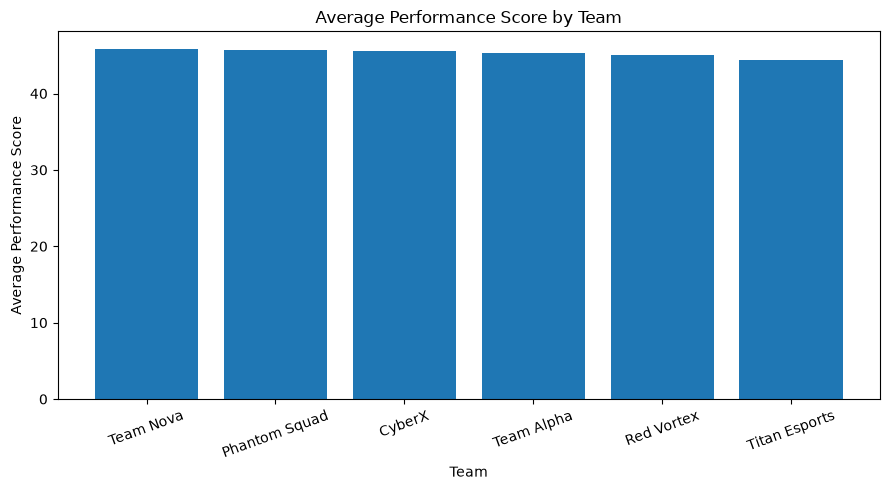

,average_performance_score
team_name,
Team Nova,45.85
Phantom Squad,45.69
CyberX,45.51
Team Alpha,45.31
Red Vortex,45.09
Titan Esports,44.38


In [12]:
team_perf = (
    df.groupby("team_name")["performance_score"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))
plt.bar(team_perf.index, team_perf.values)
plt.title("Average Performance Score by Team")
plt.xlabel("Team")
plt.ylabel("Average Performance Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(team_perf.to_frame("average_performance_score").round(2))


## 8. Match-Type Analysis

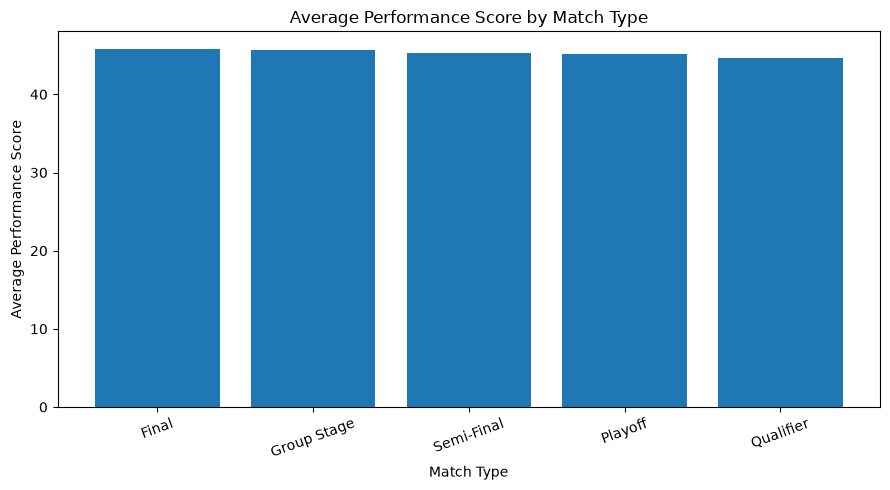

,average_performance_score
match_type,
Final,45.77
Group Stage,45.63
Semi-Final,45.32
Playoff,45.12
Qualifier,44.64


In [13]:
match_perf = (
    df.groupby("match_type")["performance_score"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))
plt.bar(match_perf.index, match_perf.values)
plt.title("Average Performance Score by Match Type")
plt.xlabel("Match Type")
plt.ylabel("Average Performance Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(match_perf.to_frame("average_performance_score").round(2))
